# Learning the committor for Tropolone intramolecular proton-transfer with distances as inputs

Reference paper:
- _Trizio, Rossi and Parrinello, [JCP](https://doi.org/10.1063/5.0331622) (2026), [ArXiv](https://arxiv.org/abs/2602.23236)_

Connected papers:
- _Kang, Trizio and Parrinello, [Nat Comput Sci](https://doi.org/10.1038/s43588-024-00645-0) (2024), [ArXiv](https://arxiv.org/abs/2401.05279)_
- _Trizio, Kang and Parrinello, [Nat Comput Sci](https://doi.org/10.1038/s43588-025-00799-5) (2025), [ArXiv](https://arxiv.org/abs/2410.17029)_

Prerequisites: committor tutorials in the tutorial notebooks.

It is also advisable to have a look at the original committor example notebook with alanine.

Author: Enrico Trizio

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/luigibonati/mlcolvar/blob/main/docs/notebooks/examples/ex_position-less_committor.ipynb)

## Background

### Theoretical Background: Original vs Approximated Committor

The committor function q(**x**) gives the probability that a configuration reaches state B before state A, and is an optimal reaction coordinate for rare events (see also the tutorials mentioned above).

The **original method** learns q(x) by minimizing the Kolmogorov variational functional:

$$K[q(x)] = \langle |\nabla_u q(x)|^2 \rangle$$

where the gradients are taken with respect to atomic coordinates. 
This formulation is physically rigorous and targets the true committor, but is computationally expensive in training due to the need to compute coordinate gradients, especially for complex descriptors and large systems. 

An **approximated variational principle** can be found, by-passing the need for gradients with respect to the positions, replacing them with much cheaper descriptor-based gradients:

$$\tilde{K}[q(d(x))] = \langle |\nabla_d q(d(x))|^4 \rangle$$

which depends only on derivatives with respect to input descriptors. 
This is justified as an upper bound to the original functional via the Cauchy–Schwarz inequality, allowing one to avoid costly coordinate gradients while still optimizing a correlated objective.

As a result, the original method is exact but computationally demanding, while the approximated method is much cheaper and scalable, at the cost of not strictly recovering the true committor. In practice, the approximation preserves sampling efficiency and accurate free energy estimates, making it suitable for complex systems where the original approach is impractical.


**In this tutorial**, we use the intramolecular proton transfer that can occur in Tropolone, a small aromatic molecule with a funny name.

<right><img src="images/tropolone.png" width="600" /></right>


### Setup

In [1]:
# Colab setup
import os

if os.getenv("COLAB_RELEASE_TAG"):
    import subprocess
    subprocess.run('wget https://raw.githubusercontent.com/luigibonati/mlcolvar/main/colab_setup.sh', shell=True)
    cmd = subprocess.run('bash colab_setup.sh TUTORIAL', shell=True, stdout=subprocess.PIPE)
    print(cmd.stdout.decode('utf-8'))

# IMPORT PACKAGES
import torch
import lightning
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
torch.manual_seed(42)

### Initialize common objects for all iterations
Here we initialize some system-dependent variables that will be used through all the iterations without changes.

- temperature of the system
- Boltzmann constant in the right energy units

In [3]:
# temperature in Kelvin
T = 300 

# Boltzmann factor in the RIGHT ENERGY UNITS!
kb = 0.0083144621 # kJ/mol
beta = 1/(kb*T)
print(f'Beta: {beta} \n1/beta: {1/beta}')

Beta: 0.4009078751268027 
1/beta: 2.4943386299999997


## Iter 0: Unbiased data only 
In general, we start from unbaised data from the metastable states only.
This allows imposing the correct boundary conditions but is not optimal for applying the variational loss.
As a consequence, our first guess will only be little more than a classifier but it will allow us collecting more configurations that will lead to a much better model in the following iterations.

#### Load data
Here we:
1. load the data, should be done using the `create_from_dataset_from_files` function
2. assign the correct weights and labels, should be done using the `compute_committor_weights` function
3. compute the descriptors from the positions and the corresponding derivatives only once to save time and resources.

The `compute_committor_weights` expect a `bias` input, which is used to compute the correct weights from reweighting of the different trajectories/iterations, as indicated by the `data_groups` key. 
**Indeces 0 and 1 ALWAYS indicate the data that should be used for state A and B in the boundary conditions loss.**

Here, as the simulations are unbiased we initalize `bias` as a bunch of zeros.

In [4]:
from mlcolvar.utils.io import create_dataset_from_files
from mlcolvar.cvs.committor.utils import compute_committor_weights
from mlcolvar.data import DictModule

filenames = ['https://github.com/EnricoTrizio/ceci_nest_pas_un_committor/raw/refs/heads/main/tropolone/data/unbiased/COLVAR_A',
             'https://github.com/EnricoTrizio/ceci_nest_pas_un_committor/raw/refs/heads/main/tropolone/data/unbiased/COLVAR_B',
            ]

load_args = [{'start' : 0, 'stop': 1600, 'stride': 1},
             {'start' : 0, 'stop': 1600, 'stride': 1},
            ]           

# load data
dataset, dataframe = create_dataset_from_files(file_names = filenames,
                                               create_labels = True,
                                               filter_args={'regex' : 'x[1-9]|x[1-2][0-9]'},
                                               return_dataframe = True,
                                               load_args=load_args,
                                               verbose = True)

# zeroth iteration should be unbiased, we thus initialize the bias as zero
bias = torch.zeros(len(dataset))

# compute weights
dataset = compute_committor_weights(dataset=dataset, 
                                    bias=bias, 
                                    data_groups=[0, 1], 
                                    beta=beta)

# initialize datamodule
datamodule = DictModule(dataset, lengths=[1])

Class 0 dataframe shape:  (1600, 41)
Class 1 dataframe shape:  (1600, 41)

 - Loaded dataframe (3200, 41): ['time', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20', 'x21', 'x22', 'x23', 'x24', 'x25', 'x26', 'x27', 'x28', 'x29', 'x30', 'x31', 'x32', 'x33', 'x34', 'x35', 'x36', 'x37', 'x38', 'walker', 'labels']
 - Descriptors (3200, 38): ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20', 'x21', 'x22', 'x23', 'x24', 'x25', 'x26', 'x27', 'x28', 'x29', 'x30', 'x31', 'x32', 'x33', 'x34', 'x35', 'x36', 'x37', 'x38']


#### Visualize training set
It is useful to visualize the training set in a space defined by some physical descriptors that can be accessed using the indexing of the `dataframe` we just loaded.
Two useful things to check are the labels of the points and their weights.

Here, for example, we can use the plane defined by the distances of the reactive hydrogen from the two oxygens.

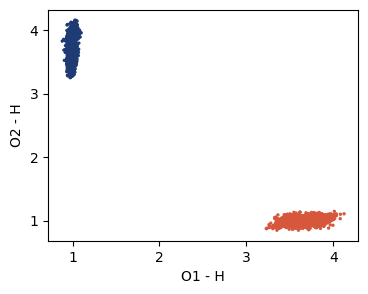

In [6]:
from mlcolvar.utils.plot import paletteFessa

plt.figure(figsize=(4,3))
plt.scatter(dataframe['x1'], dataframe['x2'], c=dataframe['labels'], cmap='fessa', s=2)
plt.xlabel('O1 - H'); plt.ylabel('O2 - H'); plt.yticks([1,2,3,4])
plt.show()

#### Initialize model
Here we initialize the model using the `Committor` class and we save the `Sigmoid` activation function that transforms $z \rightarrow q$ as $$ q = \sigma(z)$$ this way, we can easily turn it on and off to access the two quantities.

For the position-less committor, a few keyword need to be set:
- `use_gradients_wrt_positions = False`
- `atomic_masses = None`
- `norm_in` optionally, if the values of the inputs are very different from each other, it's better to set this to `True`.
- `alpha` and `gamma` should be tuned to have a balanced optimization of the boundary term and the variational one.

As for the original committor method, it is better to set a learning rate scheduler for the training, lr_scheduler `gamma` of 0.99999 (slower decay) or 0.9999 (faster decay) are fine most of the cases.

In [19]:
from mlcolvar.cvs.committor import Committor
import copy

# initialize lr scheduler
lr_scheduler = torch.optim.lr_scheduler.ExponentialLR

# create options dictionary
options = {'optimizer' : {'lr': 1e-3, 'weight_decay': 1e-5}, 
           'lr_scheduler' : { 'scheduler' : lr_scheduler, 'gamma' : 0.99995 },
            'nn' : {'activation' : 'tanh'}}

# initialize model
model = Committor(layers=[38, 16, 16, 1],
                         atomic_masses=None,
                         alpha=1,
                         options=options, 
                         separate_boundary_dataset=False,
                         descriptors_derivatives=None,
                         norm_in=False,
                         log_var=True,
                         use_gradients_wrt_positions=False,
                         )

# copy the last layer sigmoid activation function so we can enable/disable it
Sigmoid = copy.copy(model.sigmoid)

### Train model
The training with the approaximated varaitional principle is **much faster** than with the original principle, as we are by-passing the expensive propagation of gradients up to the atomic positions!

In [ ]:
from mlcolvar.utils.trainer import MetricsCallback

# define callbacks
metrics = MetricsCallback()


# initialize trainer, for testing the number of epochs is low, change this to something like 5000/100000
trainer = lightning.Trainer(callbacks=[metrics], 
                            max_epochs=5, 
                            logger=False, 
                            enable_checkpointing=False, # disabling or softening checkpointing could make it faster
                            limit_val_batches=0,    # this to skip validation
                            num_sanity_val_steps=0  # this to skip validation
                            )

# fit model
trainer.fit(model, datamodule)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type           | Params | In sizes | Out sizes
------------------------------------------------------------------
0 | loss_fn | CommittorLoss  | 0      | ?        | ?        
1 | nn      | FeedForward    | 913    | [1, 38]  | [1, 1]   
2 | sigmoid | Custom_Sigmoid | 0      | [1, 1]   | [1, 1]   
------------------------------------------------------------------
913       Trainable params
0         Non-trainable params
913       Total params
0.004     Total estimated model params size (MB)


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5000` reached.


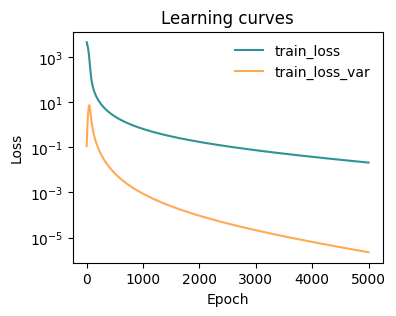

In [21]:
from mlcolvar.utils.plot import plot_metrics

# plot metrics
fig, ax = plt.subplots(1,1,figsize=(4,3))
ax = plot_metrics(metrics.metrics,
                  keys=['train_loss', 'train_loss_var'],
                  colors=['fessa1', 'fessa5'],
                  yscale='log',
                  ax = ax)

#### Visualize results
It is better to check what the model is doing on the points we have at hand.
We look at the behaviour of:
- committor CV $z$, deactivating `model.sigmoid=None`
- committor $q$, activating `model.sigmoid=Sigmoid`
- Kolmogorov bias $V_K$, using the `KolmogorovBias` helper class

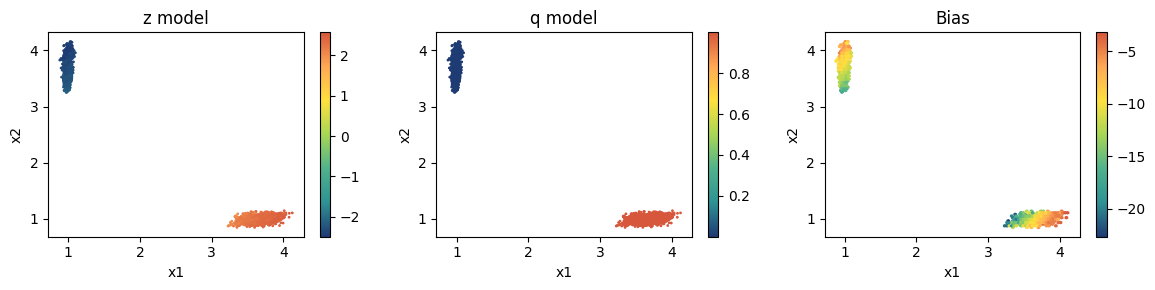

In [26]:
from mlcolvar.cvs.committor.utils import KolmogorovBias

fig, axs = plt.subplots(1,3,figsize=(12,3))

# plot z --> activation off
model.sigmoid = None

ax = axs[0]
ax.set_title('z model')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
aux = model(dataset['data'])
cp = ax.scatter(dataframe['x1'], dataframe['x2'], c=aux.cpu().detach().numpy(), s=1, cmap='fessa')
plt.colorbar(cp, ax=ax)


# plot q --> activation on
model.sigmoid = Sigmoid

ax = axs[1]
ax.set_title('q model')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
aux = model(dataset['data'])
cp = ax.scatter(dataframe['x1'], dataframe['x2'],c=aux.cpu().detach().numpy(), s=1, cmap='fessa')
plt.colorbar(cp, ax=ax)


# plot Kolmogorov bias --> activation on
model.sigmoid = Sigmoid

ax = axs[2]
ax.set_title('Bias')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
bias_model = KolmogorovBias(model, lambd=2, beta=beta, epsilon=1e-6) # can also try with epsilon=1
aux = bias_model((dataset['data']))
cp = ax.hexbin(dataframe['x1'], dataframe['x2'], C=aux.cpu().detach().numpy(), cmap='fessa')
plt.colorbar(cp, ax=ax)

plt.tight_layout()
plt.show()

In [28]:
iter = 0

# export z model --> activation off
model.sigmoid = None
model.to_torchscript(f'model_{iter}_z.pt', method='trace')

# export q model --> activation on
model.sigmoid = Sigmoid
model.to_torchscript(f'model_{iter}_q.pt', method='trace')

Committor(
  original_name=Committor
  (loss_fn): CommittorLoss(original_name=CommittorLoss)
  (nn): FeedForward(
    original_name=FeedForward
    (nn): Sequential(
      original_name=Sequential
      (0): Linear(original_name=Linear)
      (1): Tanh(original_name=Tanh)
      (2): Linear(original_name=Linear)
      (3): Tanh(original_name=Tanh)
      (4): Linear(original_name=Linear)
    )
  )
  (sigmoid): Custom_Sigmoid(original_name=Custom_Sigmoid)
)

#### Run plumed simulations
Here it is convient to create a submission script that updates the input file depending on the iteration you ar at and launches the simulations.

One good approach is to have a template simulation folder with all the inputs and then call the models, simulations folder etc. with progressive names based on the iterations. 
This way it is easy to write a script that depending on the iteration yuo are it changes the few parts that need to be changed in the input files.

For example:


`RUN_SIMULATION = f"cd biased_sims && bash generate_and_run_sims.sh {iter}"`

`subprocess.run(f"{RUN_SIMULATION}", shell=True, executable='/bin/bash')`

#### Visualize sampling
Having a structure makes it also easier to load the simulation results. Here we load them from GitHub.

We start to have a few transitions!

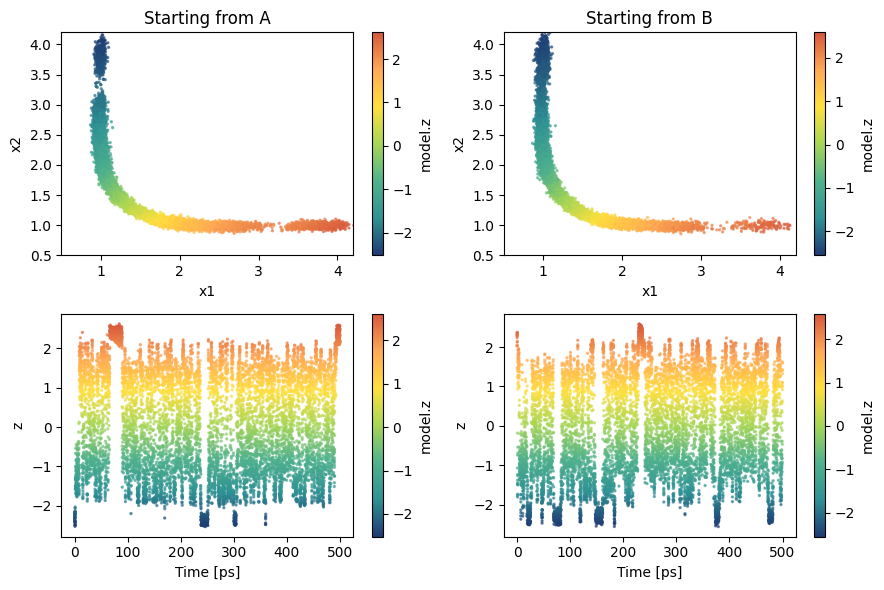

In [29]:
from mlcolvar.utils.io import load_dataframe

sampling = load_dataframe(['https://github.com/EnricoTrizio/ceci_nest_pas_un_committor/raw/refs/heads/main/tropolone/data/biased/iter_0/COLVAR_A',
                           'https://github.com/EnricoTrizio/ceci_nest_pas_un_committor/raw/refs/heads/main/tropolone/data/biased/iter_0/COLVAR_B'], 
                           start=0)

fig, axs = plt.subplots(2,2,figsize=(9,6))

color_var = 'model.z'

for i,s in enumerate(['A', 'B']):
    ax = axs[0, i]
    ax.set_title(f'Starting from {s}')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    temp = sampling[sampling['walker'] == i] # we load one simulation per time
    cp = ax.scatter(temp['x1'], temp['x2'], c=temp['model.z'], cmap='fessa',s=2, alpha=0.6)
    cb = plt.colorbar(cp, ax=ax, label='model.z')
    cb.solids.set(alpha=1)
    ax.set_xlim(0.5, 4.2)
    ax.set_ylim(0.5, 4.2)
    
    ax = axs[1, i]
    ax.set_xlabel('Time [ps]')
    ax.set_ylabel('z')
    cp = ax.scatter(temp['time'], temp['model.z'], c=temp[color_var], cmap='fessa',s=2, alpha=0.6)
    cb = plt.colorbar(cp, ax=ax, label=color_var)
    cb.solids.set(alpha=1)


plt.tight_layout()
plt.show()

## Iter 1 and on
From iteration 1 we can incorporate in our dataset the new data we generated in the previous iterations and obtain a much better estimate for the committor.

The all code below can be copied and adapted for later iterations! You only need to change:
- The files to be loaded: the first two are always the same as they are for the boundary loss, the other change. At the beginning, when we are far from convergence and the model is still rough, it makes sense to **add** the new data to the previous training set. Later, as the model and the sampling improve, it is better to **replace** the existing data with the new ones.
- number of iteration `iter` if used in an automated fashion (advised)
- eventually the number of training epochs. If the dataset is not good yet, shorter traininings are ok (i.e., 1/10000 epochs). When the dataset looks solid and covers the whole space and you can see multiple tranisitions in the biased simulations, you can also try longer trainings and aim for finer optimization (i.e., 20000 epochs)

#### Load data
Now we need to set `separate_boundary_dataset=True` and to fill the empty entries of the `dataframe['bias']` and `dataframe['opes.bias']` columns associated with the unbiased data

In [30]:
filenames = ['https://github.com/EnricoTrizio/ceci_nest_pas_un_committor/raw/refs/heads/main/tropolone/data/unbiased/COLVAR_A',
             'https://github.com/EnricoTrizio/ceci_nest_pas_un_committor/raw/refs/heads/main/tropolone/data/unbiased/COLVAR_B',
             'https://github.com/EnricoTrizio/ceci_nest_pas_un_committor/raw/refs/heads/main/tropolone/data/biased/iter_0/COLVAR_A',
             'https://github.com/EnricoTrizio/ceci_nest_pas_un_committor/raw/refs/heads/main/tropolone/data/biased/iter_0/COLVAR_B', 
            ]

load_args = [{'start' : 0, 'stop': 1600, 'stride': 1},
             {'start' : 0, 'stop': 1600, 'stride': 1},
             {'start' : 1000, 'stop': 10000, 'stride': 1},
             {'start' : 1000, 'stop': 10000, 'stride': 1},
            ]           

# load data
dataset, dataframe = create_dataset_from_files(file_names = filenames,
                                               create_labels = True,
                                               filter_args={'regex' : 'x[1-9]|x[1-2][0-9]'},
                                               return_dataframe = True,
                                               load_args=load_args,
                                               verbose = True)

# get bias
dataframe = dataframe.fillna({'opes.bias': 0, 'model.kbias' : 0})
bias = torch.Tensor(dataframe['opes.bias'].values + dataframe['model.kbias'].values)

# compute weights
dataset = compute_committor_weights(dataset=dataset, 
                                    bias=bias, 
                                    data_groups=[0, 1, 2, 3], 
                                    beta=beta)


# initialize datamodule
datamodule = DictModule(dataset, lengths=[1])

Class 0 dataframe shape:  (1600, 41)
Class 1 dataframe shape:  (1600, 41)
Class 2 dataframe shape:  (9000, 51)
Class 3 dataframe shape:  (9000, 51)

 - Loaded dataframe (21200, 51): ['time', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20', 'x21', 'x22', 'x23', 'x24', 'x25', 'x26', 'x27', 'x28', 'x29', 'x30', 'x31', 'x32', 'x33', 'x34', 'x35', 'x36', 'x37', 'x38', 'walker', 'labels', 'model.z', 'model.q', 'model.kbias', '@44.bias', '@44.model.kbias_bias', 'opes.bias', 'opes.rct', 'opes.zed', 'opes.neff', 'opes.nker']
 - Descriptors (21200, 38): ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20', 'x21', 'x22', 'x23', 'x24', 'x25', 'x26', 'x27', 'x28', 'x29', 'x30', 'x31', 'x32', 'x33', 'x34', 'x35', 'x36', 'x37', 'x38']


#### Visualize training set

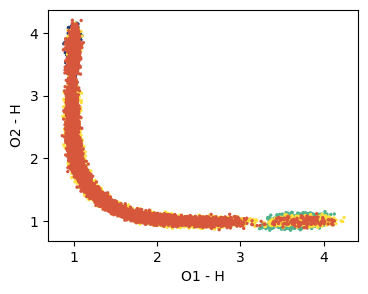

In [31]:
plt.figure(figsize=(4,3))
plt.scatter(dataframe['x1'], dataframe['x2'], c=dataframe['labels'], cmap='fessa', s=2)
plt.xlabel('O1 - H'); plt.ylabel('O2 - H'); plt.yticks([1,2,3,4])
plt.show()

#### Initialize model
Now we need to set `separate_boundary_dataset=True`

In [33]:
# initialize lr scheduler
lr_scheduler = torch.optim.lr_scheduler.ExponentialLR

# create options dictionary
options = {'optimizer' : {'lr': 1e-3, 'weight_decay': 1e-5}, 
           'lr_scheduler' : { 'scheduler' : lr_scheduler, 'gamma' : 0.99995 },
            'nn' : {'activation' : 'tanh'}}

# initialize model
model = Committor(layers=[38, 16, 16, 1],
                         atomic_masses=None,
                         alpha=1,
                         options=options, 
                         separate_boundary_dataset=True,
                         descriptors_derivatives=None,
                         norm_in=False,
                         log_var=True,
                         use_gradients_wrt_positions=False,
                         )

# copy the last layer sigmoid activation function so we can enable/disable it
Sigmoid = copy.copy(model.sigmoid)

### Train model

In [34]:
# define callbacks
metrics = MetricsCallback()


# initialize trainer, for testing the number of epochs is low, change this to something like 5000/100000
trainer = lightning.Trainer(callbacks=[metrics], 
                            max_epochs=5, 
                            logger=False, 
                            enable_checkpointing=False, # disabling or softening checkpointing could make it faster
                            limit_val_batches=0,    # this to skip validation
                            num_sanity_val_steps=0  # this to skip validation
                            )

# fit model
trainer.fit(model, datamodule)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type           | Params | In sizes | Out sizes
------------------------------------------------------------------
0 | loss_fn | CommittorLoss  | 0      | ?        | ?        
1 | nn      | FeedForward    | 913    | [1, 38]  | [1, 1]   
2 | sigmoid | Custom_Sigmoid | 0      | [1, 1]   | [1, 1]   
------------------------------------------------------------------
913       Trainable params
0         Non-trainable params
913       Total params
0.004     Total estimated model params size (MB)


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20000` reached.


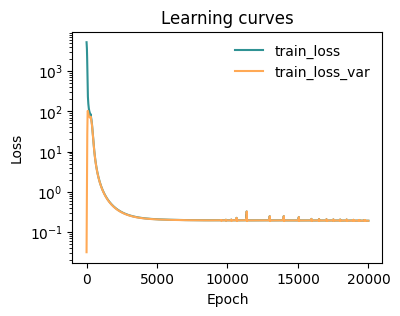

In [35]:
# plot metrics
fig, ax = plt.subplots(1,1,figsize=(4,3))
ax = plot_metrics(metrics.metrics,
                  keys=['train_loss', 'train_loss_var'],
                  colors=['fessa1', 'fessa5'],
                  yscale='log',
                  ax = ax)

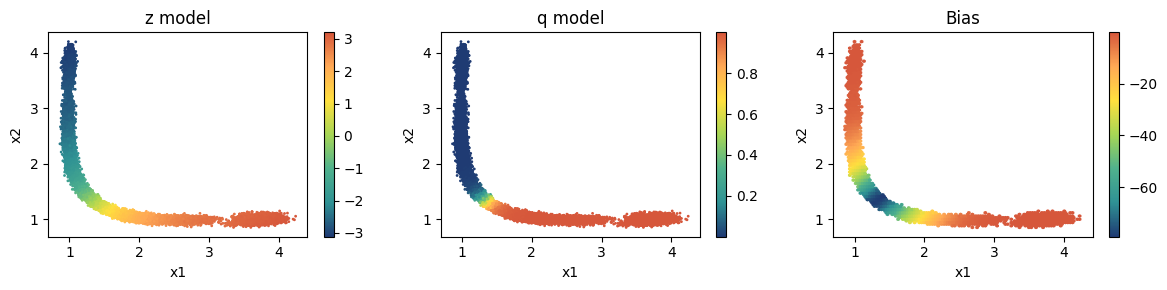

In [36]:
fig, axs = plt.subplots(1,3,figsize=(12,3))

# plot z --> activation off
model.sigmoid = None

ax = axs[0]
ax.set_title('z model')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
aux = model(dataset['data'])
cp = ax.scatter(dataframe['x1'], dataframe['x2'], c=aux.cpu().detach().numpy(), s=1, cmap='fessa')
plt.colorbar(cp, ax=ax)


# plot q --> activation on
model.sigmoid = Sigmoid

ax = axs[1]
ax.set_title('q model')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
aux = model(dataset['data'])
cp = ax.scatter(dataframe['x1'], dataframe['x2'],c=aux.cpu().detach().numpy(), s=1, cmap='fessa')
plt.colorbar(cp, ax=ax)


# plot Kolmogorov bias --> activation on
model.sigmoid = Sigmoid

ax = axs[2]
ax.set_title('Bias')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
bias_model = KolmogorovBias(model, lambd=2, beta=beta, epsilon=1e-6) # can also try with epsilon=1
aux = bias_model((dataset['data']))
cp = ax.hexbin(dataframe['x1'], dataframe['x2'], C=aux.cpu().detach().numpy(), cmap='fessa')
plt.colorbar(cp, ax=ax)

plt.tight_layout()
plt.show()

In [37]:
iter = 1

# export z model --> activation off
model.sigmoid = None
model.to_torchscript(f'model_{iter}_z.pt', method='trace')

# export q model --> activation on
model.sigmoid = Sigmoid
model.to_torchscript(f'model_{iter}_q.pt', method='trace')

Committor(
  original_name=Committor
  (loss_fn): CommittorLoss(original_name=CommittorLoss)
  (nn): FeedForward(
    original_name=FeedForward
    (nn): Sequential(
      original_name=Sequential
      (0): Linear(original_name=Linear)
      (1): Tanh(original_name=Tanh)
      (2): Linear(original_name=Linear)
      (3): Tanh(original_name=Tanh)
      (4): Linear(original_name=Linear)
    )
  )
  (sigmoid): Custom_Sigmoid(original_name=Custom_Sigmoid)
)

#### Run plumed simulations
Here it is convient to create a submission script that updates the input file depending on the iteration you ar at and launches the simulations.

One good approach is to have a template simulation folder with all the inputs and then call the models, simulations folder etc. with progressive names based on the iterations. 
This way it is easy to write a script that depending on the iteration yuo are it changes the few parts that need to be changed in the input files.

For example:


`RUN_SIMULATION = f"cd biased_sims && bash generate_and_run_sims.sh {iter}"`

`subprocess.run(f"{RUN_SIMULATION}", shell=True, executable='/bin/bash')`

#### Visualize sampling
Having a structure makes it also easier to load the simulation results. Here we load them from GitHub.

We now have a better sampling, it will eventually get even better!

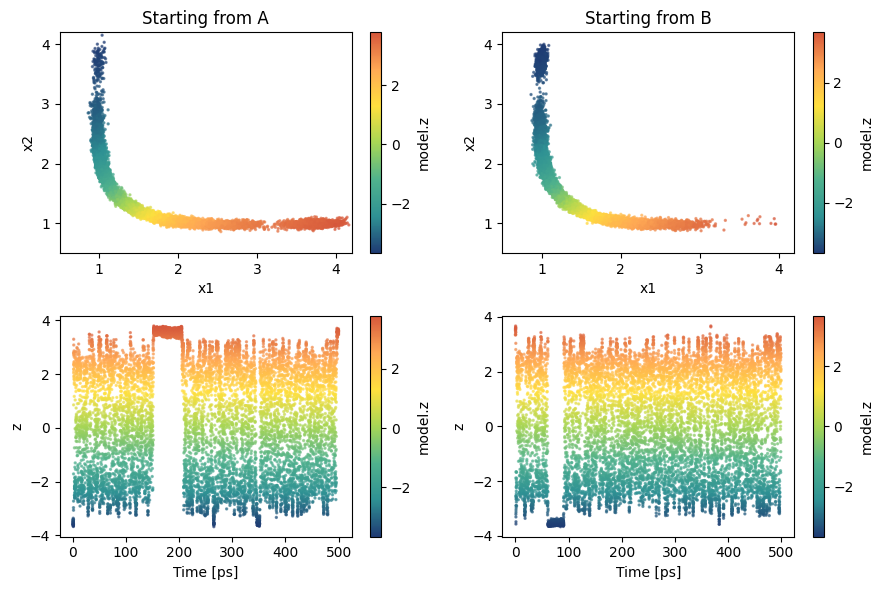

In [38]:
from mlcolvar.utils.io import load_dataframe

sampling = load_dataframe(['https://github.com/EnricoTrizio/ceci_nest_pas_un_committor/raw/refs/heads/main/tropolone/data/biased/iter_1/COLVAR_A',
                           'https://github.com/EnricoTrizio/ceci_nest_pas_un_committor/raw/refs/heads/main/tropolone/data/biased/iter_1/COLVAR_B'], 
                           start=0)

fig, axs = plt.subplots(2,2,figsize=(9,6))

color_var = 'model.z'

for i,s in enumerate(['A', 'B']):
    ax = axs[0, i]
    ax.set_title(f'Starting from {s}')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    temp = sampling[sampling['walker'] == i] # we load one simulation per time
    cp = ax.scatter(temp['x1'], temp['x2'], c=temp['model.z'], cmap='fessa',s=2, alpha=0.6)
    cb = plt.colorbar(cp, ax=ax, label='model.z')
    cb.solids.set(alpha=1)
    ax.set_xlim(0.5, 4.2)
    ax.set_ylim(0.5, 4.2)
    
    ax = axs[1, i]
    ax.set_xlabel('Time [ps]')
    ax.set_ylabel('z')
    cp = ax.scatter(temp['time'], temp['model.z'], c=temp[color_var], cmap='fessa',s=2, alpha=0.6)
    cb = plt.colorbar(cp, ax=ax, label=color_var)
    cb.solids.set(alpha=1)


plt.tight_layout()
plt.show()